In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

file_path = "/content/drive/MyDrive/assignment/IMDB Dataset.csv"

df = pd.read_csv(file_path)

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
print(df.shape)

(50000, 2)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
df.isnull().sum()

,0
review,0
sentiment,0


In [7]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


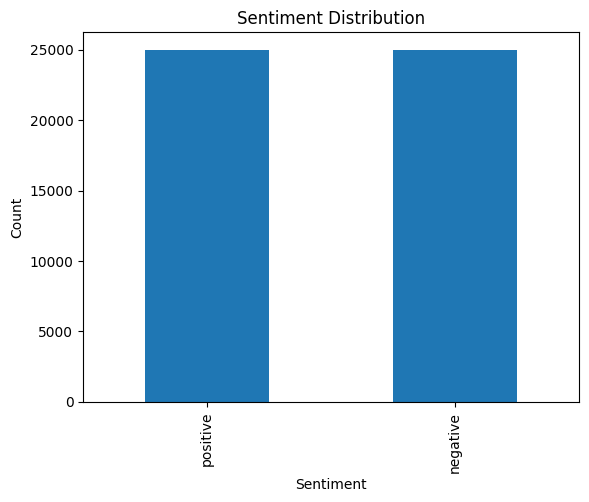

In [8]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [9]:
for i in range(5):
    print("Review:", df['review'][i])
    print("Sentiment:", df['sentiment'][i])
    print("-"*50)

Review: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to

In [10]:
df['review_length'] = df['review'].apply(len)

print(df['review_length'].describe())

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64


In [17]:
import re
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [18]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [19]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [20]:
def preprocess_text(text):

    # 1. lowercase
    text = text.lower()

    # 2. remove html tags like <br />
    text = re.sub(r'<.*?>', '', text)

    # 3. remove urls
    text = re.sub(r'http\S+|www\S+', '', text)

    # 4. remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 5. tokenize
    tokens = word_tokenize(text)

    # 6. remove stopwords + lemmatization
    clean_tokens = []

    for word in tokens:
        if word not in stop_words:
            lemma = lemmatizer.lemmatize(word)
            clean_tokens.append(lemma)

    return " ".join(clean_tokens)

In [21]:
sample = df['review'][0]

print("Original:\n", sample)
print("\nCleaned:\n", preprocess_text(sample))

Original:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due

In [22]:
df['clean_review'] = df['review'].apply(preprocess_text)

In [23]:
df[['review', 'clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [24]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [25]:
from sklearn.model_selection import train_test_split

X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [28]:
print("BoW Train Shape:", X_train_bow.shape)
print("TF-IDF Train Shape:", X_train_tfidf.shape)

BoW Train Shape: (40000, 5000)
TF-IDF Train Shape: (40000, 5000)


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

In [30]:
lr_model = LogisticRegression()

lr_model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [31]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [32]:
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train_tfidf, y_train)

DecisionTreeClassifier()

In [33]:
y_pred_lr = lr_model.predict(X_test_tfidf)
y_pred_nb = nb_model.predict(X_test_tfidf)
y_pred_dt = dt_model.predict(X_test_tfidf)

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [35]:
def evaluate_model(y_test, y_pred, model_name):

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Model:", model_name)
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))
    print("-" * 40)

In [36]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_nb, "Naive Bayes")
evaluate_model(y_test, y_pred_dt, "Decision Tree")

Model: Logistic Regression
Accuracy : 0.8848
Precision: 0.876
Recall   : 0.8986
F1 Score : 0.8871
----------------------------------------
Model: Naive Bayes
Accuracy : 0.8491
Precision: 0.8477
Recall   : 0.8539
F1 Score : 0.8508
----------------------------------------
Model: Decision Tree
Accuracy : 0.7172
Precision: 0.7209
Recall   : 0.716
F1 Score : 0.7184
----------------------------------------


In [37]:
from sklearn.metrics import confusion_matrix

print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression Confusion Matrix:
 [[4320  641]
 [ 511 4528]]


# Sentiment Analysis Project
## Model Comparison and Insights

In this project, I built a sentiment analysis system using different machine learning models after applying NLP preprocessing and feature engineering.

First, I cleaned the raw text data by removing HTML tags, punctuation, stopwords, and converting everything to lowercase. I also applied tokenization and lemmatization to make the text more meaningful and consistent.

For feature engineering, I used both Bag of Words and TF-IDF, and TF-IDF gave better performance, so I used it for training the models.

Model Performance
Logistic Regression
Accuracy: 88.48%
It performed the best among all models.
It was able to generalize well and handle text data efficiently.
Naive Bayes
Accuracy: 84.91%
It performed reasonably well and was faster.
Works well for text data but slightly less accurate than Logistic Regression.
Decision Tree
Accuracy: 71.72%
Lowest performance among the three.
It tends to overfit and does not perform well on high-dimensional text data.
Best Model

Logistic Regression is the best model in this case because:

It gave the highest accuracy and F1 score
It handled the TF-IDF features effectively
It balanced precision and recall well
Insights
Proper preprocessing significantly improved model performance.
Removing noise like HTML tags and stopwords helped in better feature extraction.
TF-IDF performed better than Bag of Words because it gives importance to meaningful words.
Simple models like Logistic Regression can perform very well on NLP tasks.
Conclusion

Overall, this project helped me understand how raw text data is converted into meaningful features and used in machine learning models. It also showed the importance of preprocessing and model selection in NLP tasks.